In [26]:
# Importação das bibliotecas necessárias
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [27]:
# Carregando o Dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50135)

print(f"Total de amostras: {len(X)}")
print(f"Amostras para treino: {len(X_train)} | Amostras para teste: {len(X_test)}")

Total de amostras: 150
Amostras para treino: 105 | Amostras para teste: 45


In [28]:
def fuzzy_predict(X_data):
    predictions = []
    for row in X_data:
        petal_length = row[2]

        # Grau de pertinência para Setosa
        pert_setosa = max(0, min(1, (3.0 - petal_length) / (3.0 - 2.0)))

        # Grau de pertinência para Virginica
        pert_virginica = max(0, min(1, (petal_length - 4.5) / (5.5 - 4.5)))

        # Grau de pertinência para Versicolor (o que sobra)
        pert_versicolor = max(0, 1.0 - (pert_setosa + pert_virginica))

        # A classe predita é a de maior pontuação
        scores = [pert_setosa, pert_versicolor, pert_virginica]
        predictions.append(np.argmax(scores))

    return predictions

In [29]:
# Realizando predições
y_pred_fuzzy = fuzzy_predict(X_test)
acc_fuzzy = accuracy_score(y_test, y_pred_fuzzy)
print(f"Acurácia - Lógica Fuzzy: {acc_fuzzy * 100:.2f}%")

Acurácia - Lógica Fuzzy: 93.33%


In [30]:
# ==========================================
# Exibindo Resultados Separados e Detalhados
# ==========================================

n_amostras = 15

print("1. GABARITO REAL (O que as flores realmente são):")
print(y_test[:n_amostras])
print("-" * 50)

print("\n2. RESULTADOS - LÓGICA FUZZY")
print(f"Acurácia Total: {acc_fuzzy * 100:.2f}%")
# Convertendo para numpy array para fatiar
y_pred_fuzzy_np = np.array(y_pred_fuzzy)
print(f"Predições: {y_pred_fuzzy_np[:n_amostras]}")
erros_fuzzy = sum(y_test != y_pred_fuzzy_np)
print(f"Total de erros no teste inteiro: {erros_fuzzy} de {len(y_test)} flores.")
print("-" * 50)

1. GABARITO REAL (O que as flores realmente são):
[1 0 1 1 2 0 1 2 2 0 1 2 2 1 2]
--------------------------------------------------

2. RESULTADOS - LÓGICA FUZZY
Acurácia Total: 93.33%
Predições: [1 0 1 1 1 0 1 2 2 0 1 2 2 1 2]
Total de erros no teste inteiro: 3 de 45 flores.
--------------------------------------------------


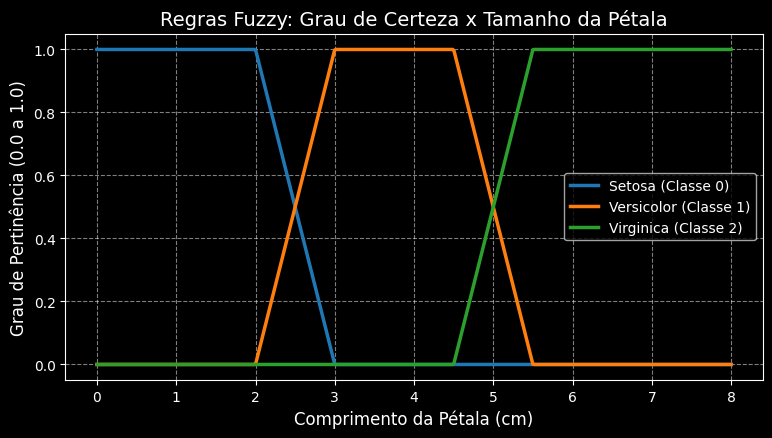

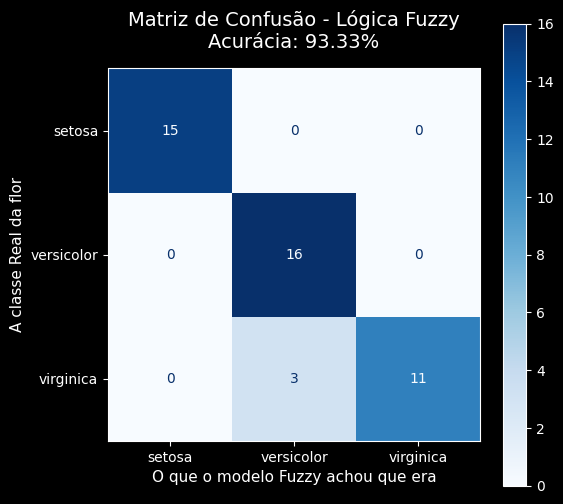

In [31]:
# ==========================================
# GRÁFICO 1: Curvas de Pertinência Fuzzy
# ==========================================
# Criando um eixo X (Comprimento da pétala de 0 a 8 cm)
x_vals = np.linspace(0, 8, 500)

# Aplicando as regras matemáticas do seu modelo a cada ponto do eixo X
y_setosa = [max(0, min(1, (3.0 - p) / (3.0 - 2.0))) for p in x_vals]
y_virginica = [max(0, min(1, (p - 4.5) / (5.5 - 4.5))) for p in x_vals]
y_versicolor = [max(0, 1.0 - (s + v)) for s, v in zip(y_setosa, y_virginica)]

plt.figure(figsize=(9, 4.5))
plt.plot(x_vals, y_setosa, label='Setosa (Classe 0)', linewidth=2.5, color='#1f77b4')
plt.plot(x_vals, y_versicolor, label='Versicolor (Classe 1)', linewidth=2.5, color='#ff7f0e')
plt.plot(x_vals, y_virginica, label='Virginica (Classe 2)', linewidth=2.5, color='#2ca02c')

plt.title('Regras Fuzzy: Grau de Certeza x Tamanho da Pétala', fontsize=14)
plt.xlabel('Comprimento da Pétala (cm)', fontsize=12)
plt.ylabel('Grau de Pertinência (0.0 a 1.0)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# ==========================================
# GRÁFICO 2: Matriz de Confusão do Modelo
# ==========================================
# Calcula a matriz usando as predições feitas anteriormente (y_pred_fuzzy) e o gabarito (y_test)
cm = confusion_matrix(y_test, y_pred_fuzzy)
nomes_classes = iris.target_names

# Plota usando o mapa de cores Azul ('Blues')
fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nomes_classes)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title(f'Matriz de Confusão - Lógica Fuzzy\nAcurácia: {acc_fuzzy * 100:.2f}%', fontsize=14, pad=15)
plt.xlabel('O que o modelo Fuzzy achou que era', fontsize=11)
plt.ylabel('A classe Real da flor', fontsize=11)
plt.show()